In [16]:
# ==============================================================
# Hospital Readmission Prediction - UCI Diabetes Dataset
# Dataset: 130 US Hospitals (1999–2008)
# Author: Aditya Subramanian
# ==============================================================

# SECTION 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [17]:
# ----------------------------------
# 1. Load dataset
# ----------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetic_data.csv')
print(df.shape)
df.head()


(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [18]:
# ----------------------------------
# 2. Data Cleaning & Preprocessing
# ----------------------------------

# Drop unique identifiers
df = df.drop(["encounter_id", "patient_nbr"], axis=1)

# Replace '?' with NaN
df = df.replace("?", np.nan)

# Map age ranges into midpoints for analysis
df["age"] = df["age"].str.strip("[]()").str.split("-").apply(
    lambda x: int(np.mean([int(i) for i in x])) if isinstance(x, list) else np.nan
)

# Weight has too many missing values; create indicator
df["weight_missing"] = df["weight"].isna().astype(int)
df = df.drop("weight", axis=1)

# Map admission_type_id, discharge_disposition_id, admission_source_id
admission_type_map = {
    1: "Emergency", 2: "Urgent", 3: "Elective", 4: "Newborn",
    5: "Not Available", 6: "NULL", 7: "Trauma Center", 8: "Not Mapped"
}

discharge_disposition_map = {
    1: "Discharged to home", 2: "Transferred to short term hospital", 3: "Transferred to SNF",
    4: "Transferred to ICF", 5: "Transferred to inpatient care institution", 6: "Home health service",
    7: "Left AMA", 8: "Home IV provider", 9: "Admitted to hospital", 10: "Neonate to another hospital",
    11: "Expired", 12: "Still patient/outpatient services", 13: "Hospice/home", 14: "Hospice/medical facility",
    15: "Medicare swing bed", 16: "Referred to outpatient services (other institution)",
    17: "Referred to outpatient services (this institution)", 18: "NULL",
    19: "Expired at home (Medicaid, hospice)", 20: "Expired in medical facility (Medicaid, hospice)",
    21: "Expired unknown (Medicaid, hospice)", 22: "Rehab facility", 23: "Long term care hospital",
    24: "Nursing facility (Medicaid, not Medicare)", 25: "Not Mapped", 26: "Unknown/Invalid",
    27: "Federal healthcare facility", 28: "Psychiatric hospital", 29: "Critical Access Hospital",
    30: "Other health care institution"
}

admission_source_map = {
    1: "Physician Referral", 2: "Clinic Referral", 3: "HMO Referral", 4: "Transfer from hospital",
    5: "Transfer from SNF", 6: "Transfer from another healthcare facility", 7: "Emergency Room",
    8: "Court/Law Enforcement", 9: "Not Available", 10: "Transfer from critical access hospital",
    11: "Normal Delivery", 12: "Premature Delivery", 13: "Sick Baby", 14: "Extramural Birth",
    15: "Not Available", 17: "NULL", 18: "Transfer from another home health agency",
    19: "Readmission to same home health agency", 20: "Not Mapped", 21: "Unknown/Invalid",
    22: "Transfer from hospital (same facility, separate claim)",
    23: "Born inside this hospital", 24: "Born outside this hospital",
    25: "Transfer from Ambulatory Surgery Center", 26: "Transfer from Hospice"
}

df['admission_type'] = df['admission_type_id'].map(admission_type_map)
df['discharge_disposition'] = df['discharge_disposition_id'].map(discharge_disposition_map)
df['admission_source'] = df['admission_source_id'].map(admission_source_map)

# For categorical columns with unknown/NULL/Not Available values
categorical_cols = ['admission_type', 'discharge_disposition', 'admission_source', 'race', 'gender']

for col in categorical_cols:
    df[col] = df[col].replace({
        'NULL': 'Unknown',
        'Not Available': 'Unknown',
        'Not Mapped': 'Unknown',
        'Unknown/Invalid': 'Unknown'
    })

# Encode target variable (readmitted)
df["readmitted"] = df["readmitted"].replace({">30": "YES", "<30": "YES", "NO": "NO"})
df["readmitted_flag"] = df["readmitted"].map({"NO":0, "YES":1})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 52 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  int64 
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   payer_code                61510 non-null   object
 8   medical_specialty         51817 non-null   object
 9   num_lab_procedures        101766 non-null  int64 
 10  num_procedures            101766 non-null  int64 
 11  num_medications           101766 non-null  int64 
 12  number_outpatient         101766 non-null  int64 
 13  number_emergency          101766 non-null  int64 
 14  numb

In [19]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,weight_missing,admission_type,discharge_disposition,admission_source,readmitted_flag
0,Caucasian,Female,5,6,25,1,1,NaN,Pediatrics-Endocrinology,41,...,No,No,No,No,NO,1,Unknown,Unknown,Physician Referral,0
1,Caucasian,Female,15,1,1,7,3,NaN,NaN,59,...,No,No,Ch,Yes,YES,1,Emergency,Discharged to home,Emergency Room,1
2,AfricanAmerican,Female,25,1,1,7,2,NaN,NaN,11,...,No,No,No,Yes,NO,1,Emergency,Discharged to home,Emergency Room,0
3,Caucasian,Male,35,1,1,7,2,NaN,NaN,44,...,No,No,Ch,Yes,NO,1,Emergency,Discharged to home,Emergency Room,0
4,Caucasian,Male,45,1,1,7,1,NaN,NaN,51,...,No,No,Ch,Yes,NO,1,Emergency,Discharged to home,Emergency Room,0


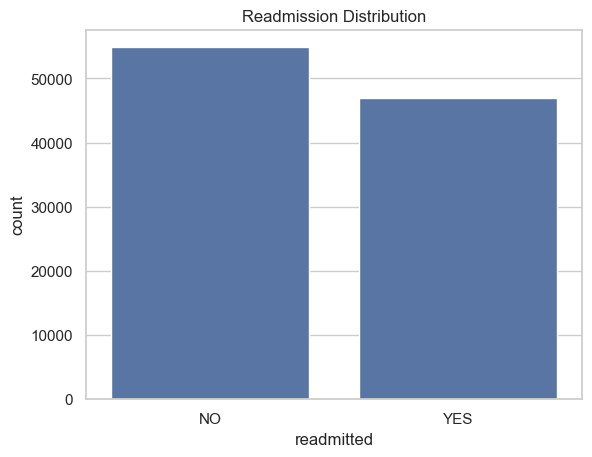

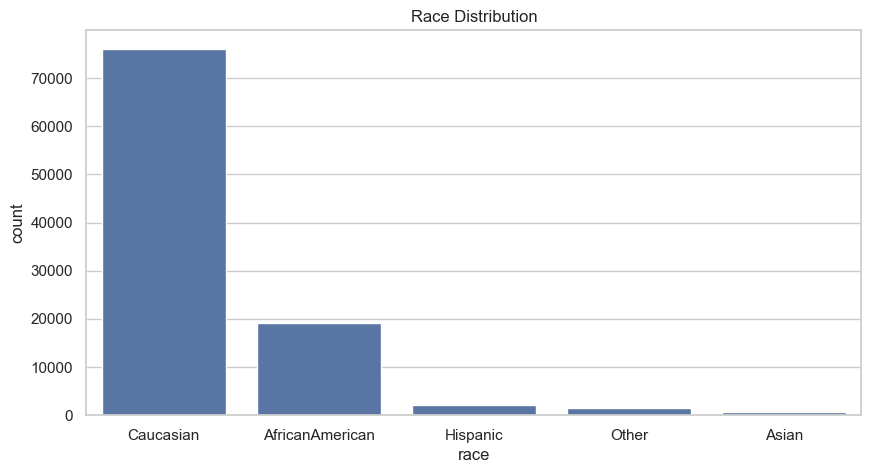

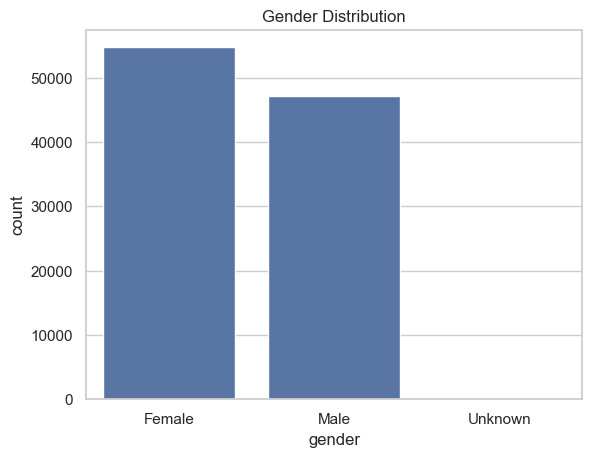

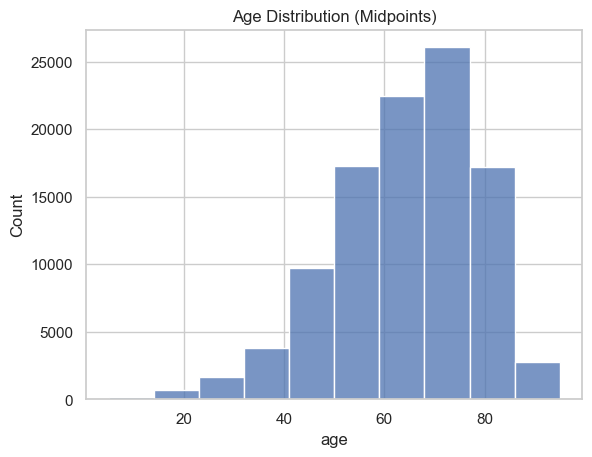

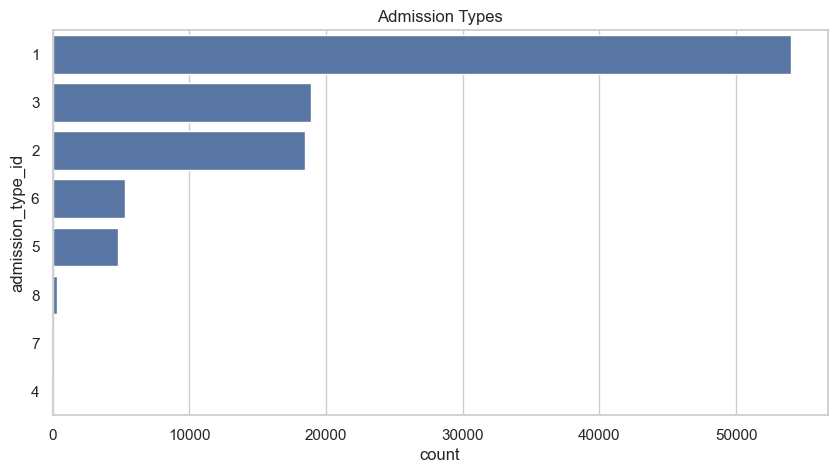

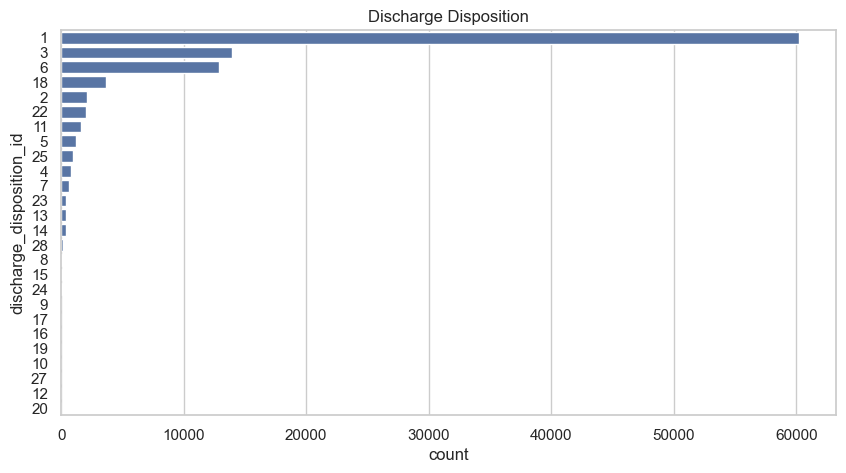

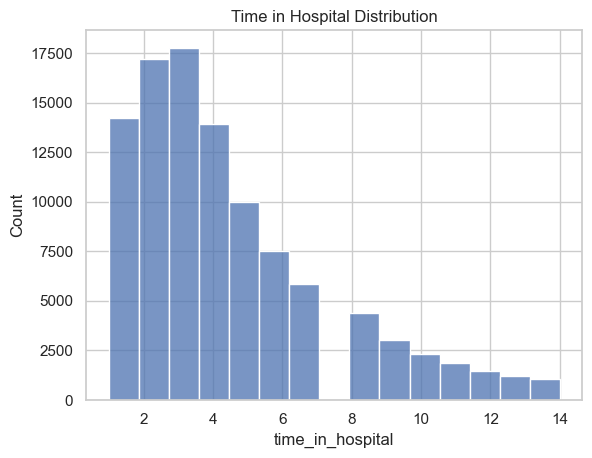

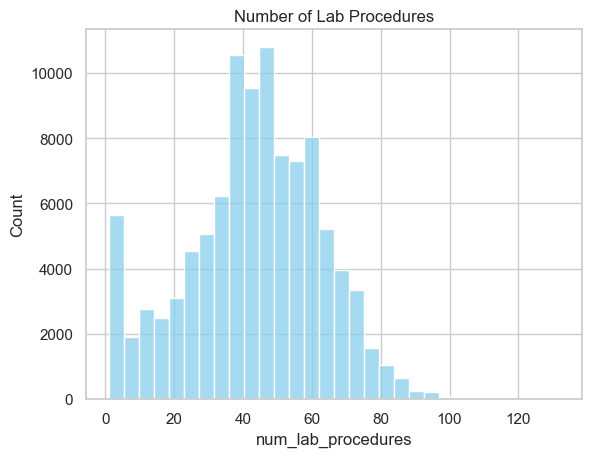

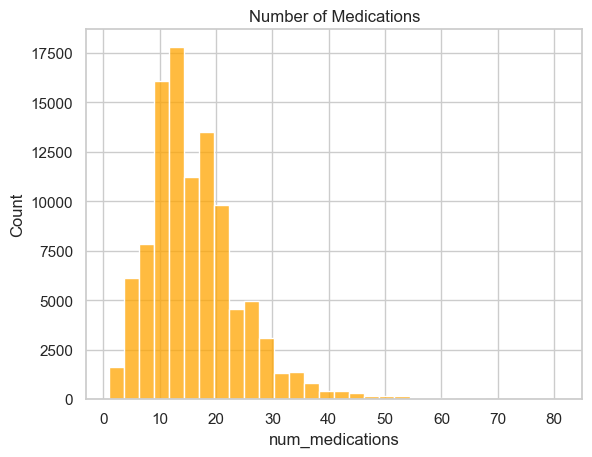

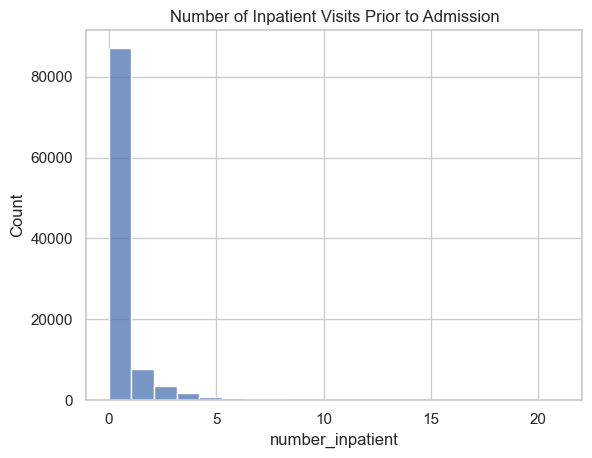

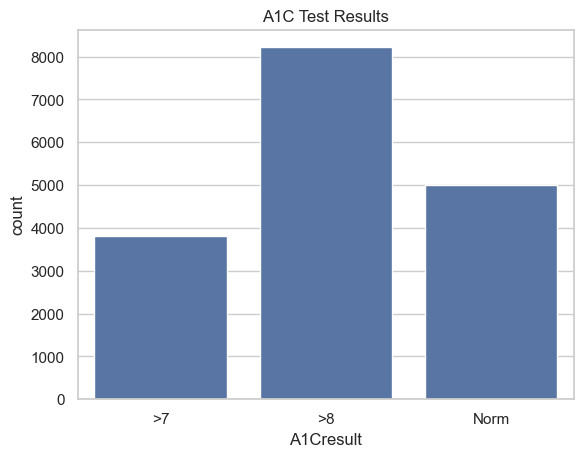

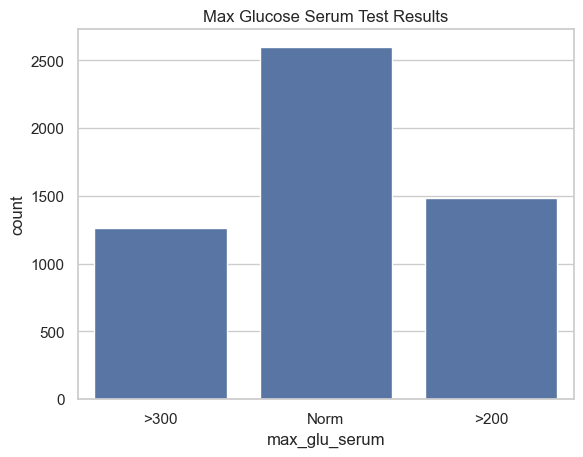

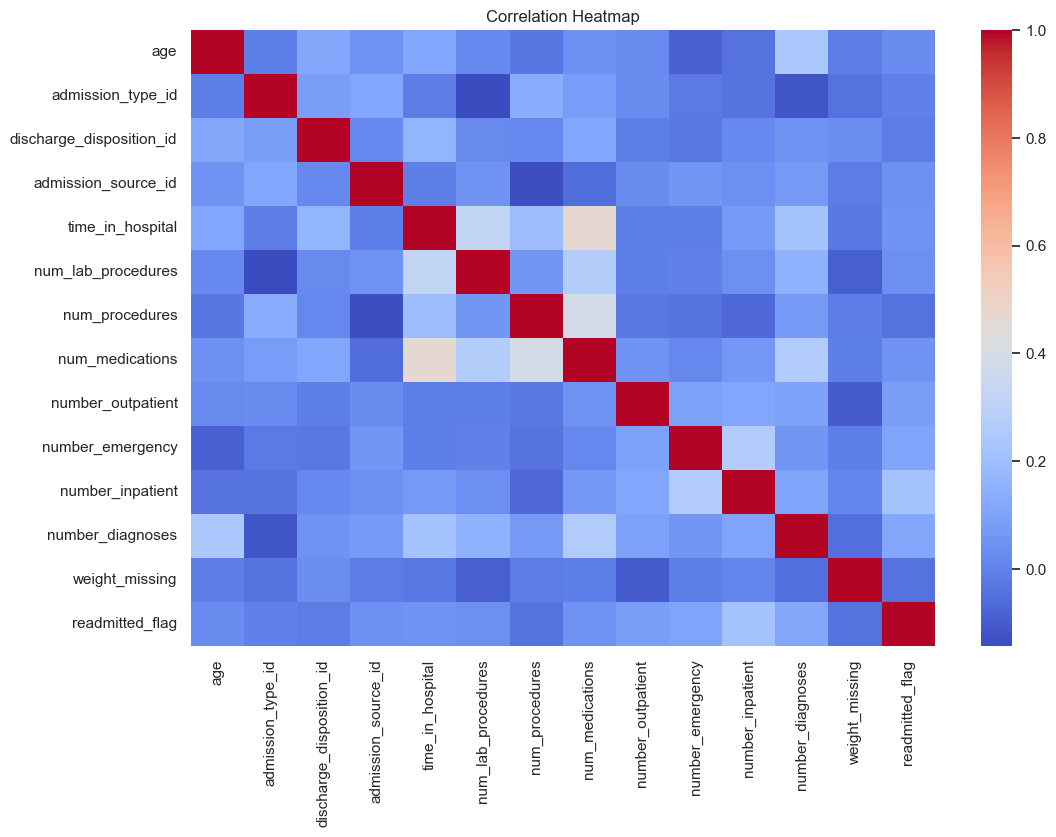

In [20]:
# ----------------------------------
# 3. Exploratory Data Analysis
# ----------------------------------

# Target distribution
sns.countplot(x="readmitted", data=df)
plt.title("Readmission Distribution")
plt.show()

# Demographics
plt.figure(figsize=(10,5))
sns.countplot(x="race", data=df, order=df["race"].value_counts().index)
plt.title("Race Distribution")
plt.show()

sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

sns.histplot(df["age"], bins=10, kde=False)
plt.title("Age Distribution (Midpoints)")
plt.show()

# Hospitalization features
plt.figure(figsize=(10,5))
sns.countplot(y="admission_type_id", data=df, order=df["admission_type_id"].value_counts().index)
plt.title("Admission Types")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(y="discharge_disposition_id", data=df, order=df["discharge_disposition_id"].value_counts().index)
plt.title("Discharge Disposition")
plt.show()

# Length of stay
sns.histplot(df["time_in_hospital"], bins=15)
plt.title("Time in Hospital Distribution")
plt.show()

# Clinical characteristics
sns.histplot(df["num_lab_procedures"], bins=30, color="skyblue")
plt.title("Number of Lab Procedures")
plt.show()

sns.histplot(df["num_medications"], bins=30, color="orange")
plt.title("Number of Medications")
plt.show()

sns.histplot(df["number_inpatient"], bins=20)
plt.title("Number of Inpatient Visits Prior to Admission")
plt.show()

# Diabetes-specific labs
sns.countplot(x="A1Cresult", data=df)
plt.title("A1C Test Results")
plt.show()

sns.countplot(x="max_glu_serum", data=df)
plt.title("Max Glucose Serum Test Results")
plt.show()

# Correlation heatmap (numeric features vs target)
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

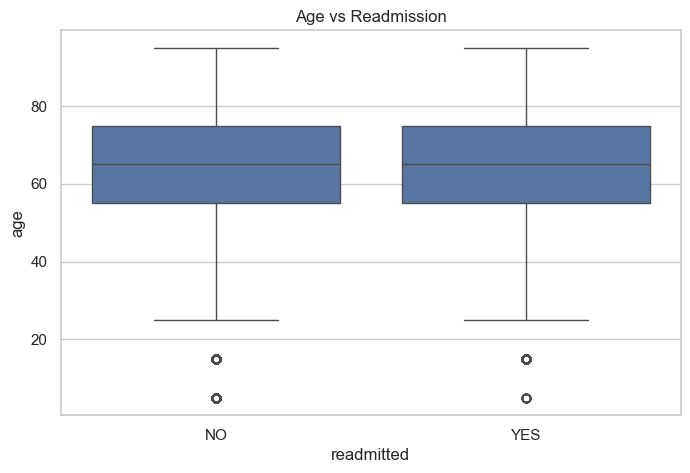

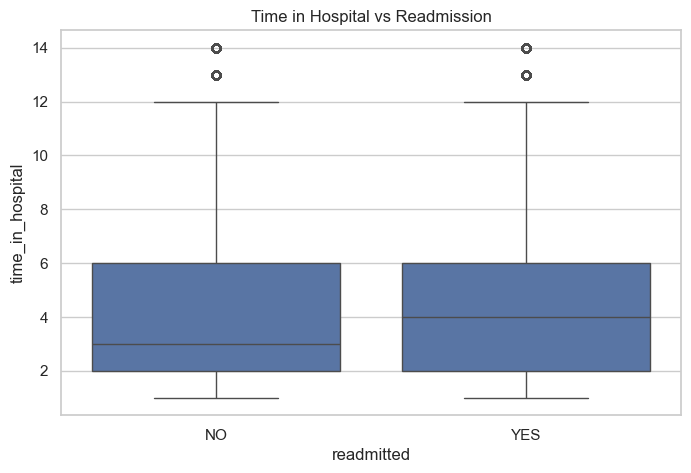

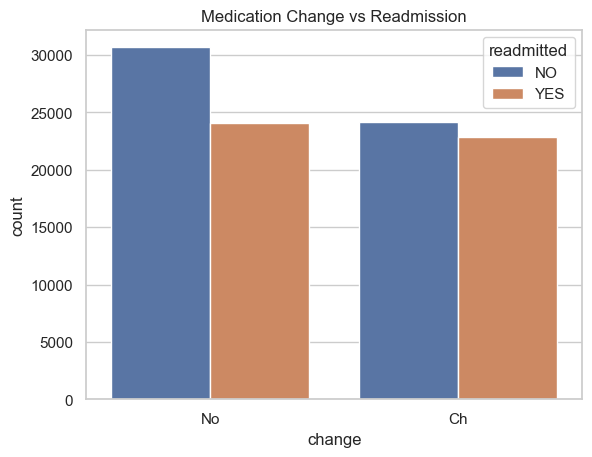

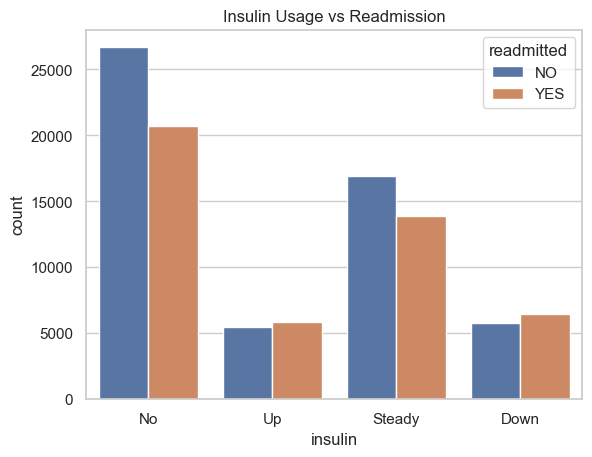

In [21]:
# ----------------------------------
# 4. Feature-Target Relationships
# ----------------------------------

# Age vs. Readmission
plt.figure(figsize=(8,5))
sns.boxplot(x="readmitted", y="age", data=df)
plt.title("Age vs Readmission")
plt.show()

# Time in hospital vs readmission
plt.figure(figsize=(8,5))
sns.boxplot(x="readmitted", y="time_in_hospital", data=df)
plt.title("Time in Hospital vs Readmission")
plt.show()

# Medication change vs readmission
sns.countplot(x="change", hue="readmitted", data=df)
plt.title("Medication Change vs Readmission")
plt.show()

# Insulin vs readmission
sns.countplot(x="insulin", hue="readmitted", data=df)
plt.title("Insulin Usage vs Readmission")
plt.show()



Admission Type Distribution:
admission_type
Emergency        53990
Elective         18869
Urgent           18480
Unknown          10396
Trauma Center       21
Newborn             10
Name: count, dtype: int64

Discharge Disposition Distribution:
discharge_disposition
Discharged to home                           60234
Transferred to SNF                           13954
Home health service                          12902
Unknown                                       4680
Transferred to short term hospital            2128
Rehab facility                                1993
Expired                                       1642
Transferred to inpatient care institution     1184
Transferred to ICF                             815
Left AMA                                       623
Name: count, dtype: int64

Admission Source Distribution:
admission_source
Emergency Room                                            57494
Physician Referral                                        29565
Unknown            

/var/folders/8z/wt62yfwd2bj43btbm7x3jflr0000gn/T/ipykernel_6854/4172809551.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='admission_type', order=df['admission_type'].value_counts().index, palette="Set2")


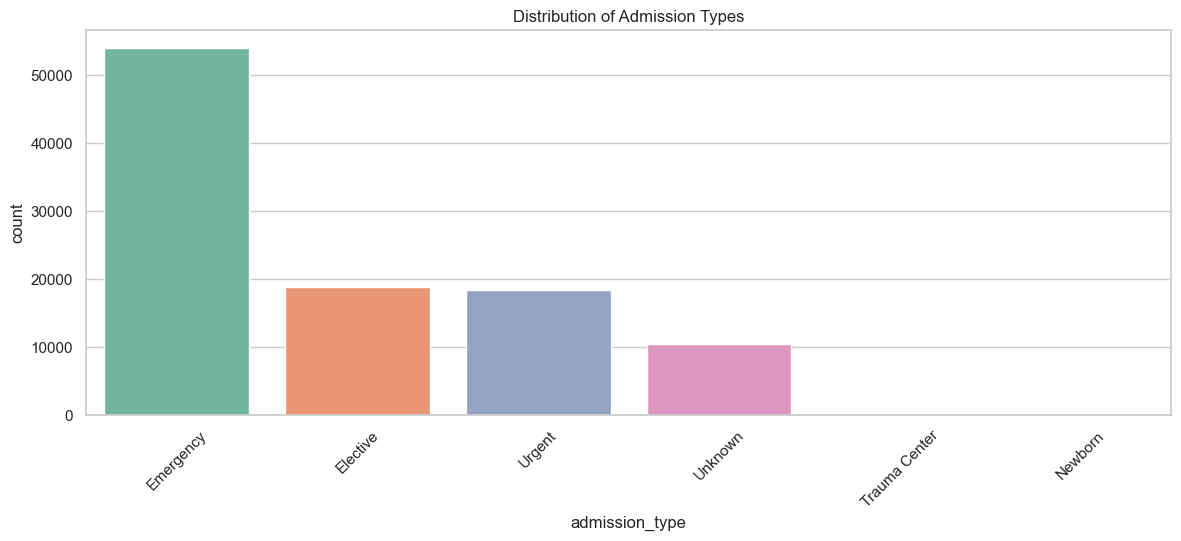

/var/folders/8z/wt62yfwd2bj43btbm7x3jflr0000gn/T/ipykernel_6854/4172809551.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='discharge_disposition', order=df['discharge_disposition'].value_counts().index[:10], palette="Set3")


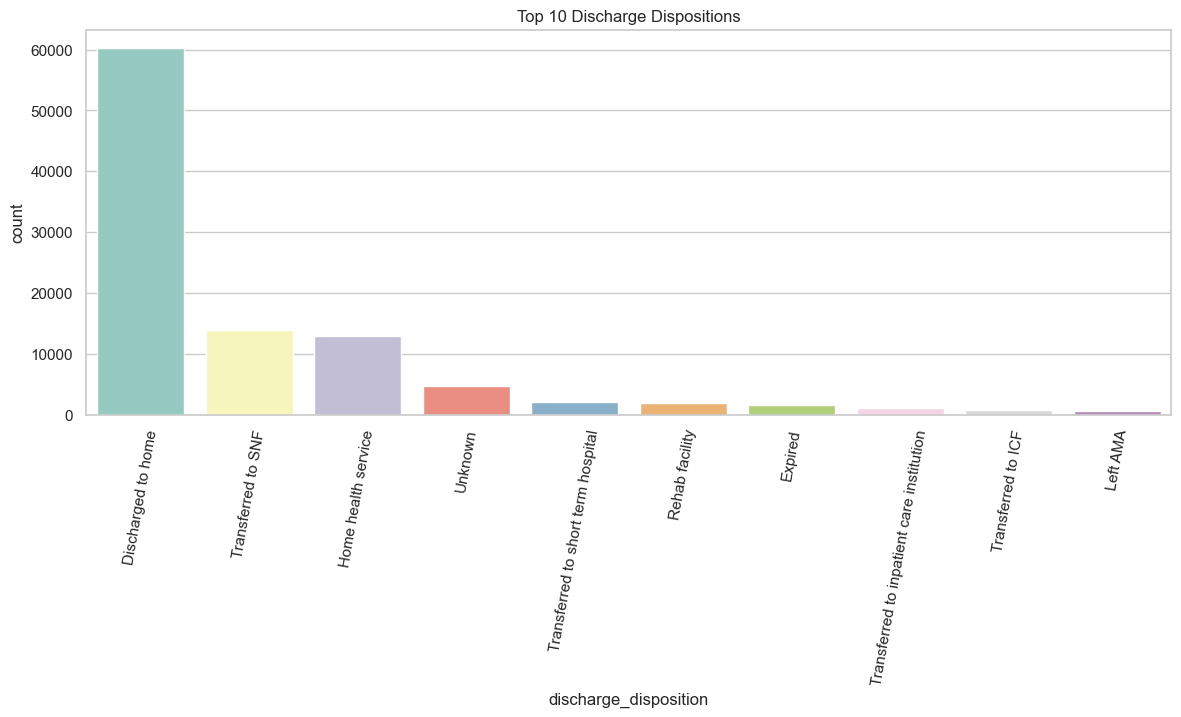

/var/folders/8z/wt62yfwd2bj43btbm7x3jflr0000gn/T/ipykernel_6854/4172809551.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='admission_source', order=df['admission_source'].value_counts().index[:10], palette="Set1")


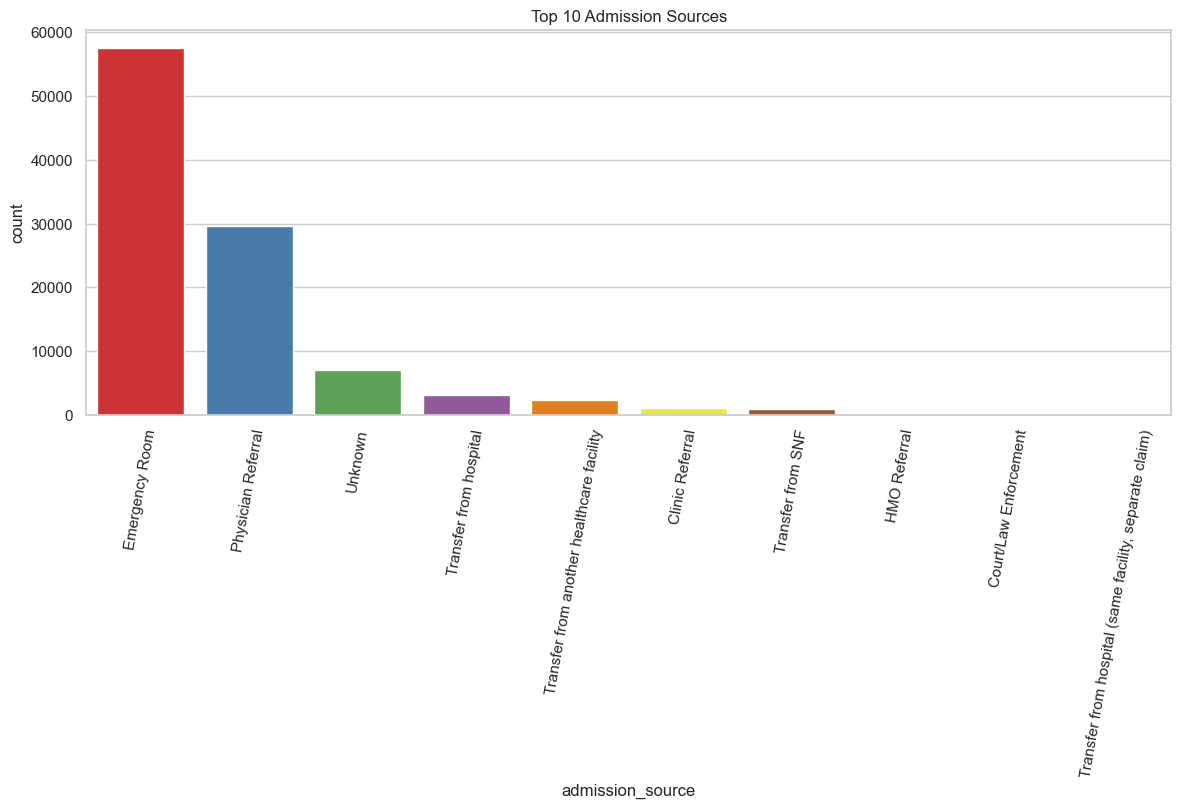

In [22]:
print("\nAdmission Type Distribution:")
print(df['admission_type'].value_counts(dropna=False))

print("\nDischarge Disposition Distribution:")
print(df['discharge_disposition'].value_counts(dropna=False).head(10))

print("\nAdmission Source Distribution:")
print(df['admission_source'].value_counts(dropna=False).head(10))

# Visualization
plt.figure(figsize=(14,5))
sns.countplot(data=df, x='admission_type', order=df['admission_type'].value_counts().index, palette="Set2")
plt.xticks(rotation=45)
plt.title("Distribution of Admission Types")
plt.show()

plt.figure(figsize=(14,5))
sns.countplot(data=df, x='discharge_disposition', order=df['discharge_disposition'].value_counts().index[:10], palette="Set3")
plt.xticks(rotation=80)
plt.title("Top 10 Discharge Dispositions")
plt.show()

plt.figure(figsize=(14,5))
sns.countplot(data=df, x='admission_source', order=df['admission_source'].value_counts().index[:10], palette="Set1")
plt.xticks(rotation=80)
plt.title("Top 10 Admission Sources")
plt.show()

In [23]:
# ===============================================
# 6. Clinical Statistical Inference
# ===============================================

import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

# -----------------------------
# 6a. Chi-square tests for categorical variables
# -----------------------------

categorical_vars = [
    'race', 'gender', 'admission_type', 'discharge_disposition',
    'admission_source', 'change', 'diabetesMed', 'insulin'
]

chi2_results = []

for var in categorical_vars:
    contingency_table = pd.crosstab(df[var], df['readmitted_flag'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    
    # Compute Cramer's V effect size
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = (chi2 / (n * min_dim))**0.5 if min_dim > 0 else np.nan
    
    chi2_results.append({
        'variable': var,
        'chi2': chi2,
        'p_value': p,
        'cramers_v': cramers_v,
        'dof': dof
    })

chi2_df = pd.DataFrame(chi2_results)

# FDR correction
chi2_df['p_adj'] = multipletests(chi2_df['p_value'], method='fdr_bh')[1]
chi2_df = chi2_df.sort_values('p_adj')

print("Chi-square tests for categorical variables vs readmission:\n")
display(chi2_df[['variable', 'chi2', 'dof', 'cramers_v', 'p_value', 'p_adj']])


Chi-square tests for categorical variables vs readmission:



,variable,chi2,dof,cramers_v,p_value,p_adj
3,discharge_disposition,2383.346435,24,0.153036,0.000000e+00,0.000000e+00
4,admission_source,1036.329921,14,0.100913,2.502310e-212,1.000924e-211
7,insulin,477.152519,3,0.068474,4.264056e-103,1.137082e-102
6,diabetesMed,384.717210,1,0.061485,1.169410e-85,2.338821e-85
2,admission_type,307.135961,5,0.054937,2.926330e-64,4.682129e-64
5,change,215.222819,1,0.045988,9.964594e-49,1.328613e-48
0,race,91.368531,4,0.030304,6.741338e-19,7.704386e-19
1,gender,35.557723,2,0.018692,1.899935e-08,1.899935e-08


In [24]:
# -----------------------------
# 6b. T-tests / Mann–Whitney U tests for numeric variables
# -----------------------------

numeric_vars = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

numeric_results = []

for var in numeric_vars:
    group0 = df[df['readmitted_flag']==0][var].dropna()
    group1 = df[df['readmitted_flag']==1][var].dropna()
    
    # Check normality with Shapiro test (optional, could skip for large n)
    # Shapiro only for smaller samples, large n => Central Limit Theorem
    
    # Mann-Whitney U test (non-parametric)
    u_stat, p_value = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    
    # Compute effect size (Cohen's d approximation)
    mean_diff = group1.mean() - group0.mean()
    pooled_sd = np.sqrt((group1.var() + group0.var())/2)
    cohen_d = mean_diff / pooled_sd if pooled_sd != 0 else np.nan
    
    numeric_results.append({
        'variable': var,
        'u_stat': u_stat,
        'cohen_d': cohen_d,
        'p_value': p_value
    })

numeric_df = pd.DataFrame(numeric_results)
numeric_df['p_adj'] = multipletests(numeric_df['p_value'], method='fdr_bh')[1]
numeric_df = numeric_df.sort_values('p_adj')

print("Non-parametric tests for numeric variables vs readmission:\n")
display(numeric_df[['variable', 'u_stat', 'cohen_d', 'p_value', 'p_adj']])


Non-parametric tests for numeric variables vs readmission:



,variable,u_stat,cohen_d,p_value,p_adj
6,number_emergency,1.183642e+09,0.202010,0.000000e+00,0.000000e+00
7,number_inpatient,1.000697e+09,0.437045,0.000000e+00,0.000000e+00
5,number_outpatient,1.180330e+09,0.163050,1.594058e-272,4.782174e-272
8,number_diagnoses,1.134381e+09,0.228254,2.509639e-264,5.646688e-264
4,num_medications,1.181497e+09,0.094244,2.408226e-112,4.334806e-112
1,time_in_hospital,1.196461e+09,0.102980,2.116668e-84,3.175002e-84
3,num_procedures,1.351895e+09,-0.090021,1.600282e-49,2.057505e-49
2,num_lab_procedures,1.225611e+09,0.078854,5.505699e-39,6.193911e-39
0,age,1.243071e+09,0.061122,2.003521e-21,2.003521e-21


## 7. Statistical Inference: Key Findings

**Categorical Variables:**
- **Discharge disposition** is the strongest predictor of readmission (Cramer's V = 0.15), indicating patients discharged to SNF or home health are more likely to return.
- **Admission source, insulin use, diabetes medications, and admission type** are also significant predictors (Cramer's V ~0.06–0.10).
- **Race and gender** are statistically significant but have very small effect sizes, suggesting limited predictive impact on their own.

**Numeric Variables:**
- **Number of prior inpatient visits (Cohen's d = 0.44)** and **number of diagnoses (d = 0.23)** are the strongest numeric predictors of readmission.
- **Number of emergency/outpatient visits, medications, and time in hospital** are significant but with smaller effects.
- **Age, lab, and procedure counts** are statistically significant but have minimal effect sizes.

**Clinical Significance:**
- Prior healthcare utilization and discharge disposition are the most clinically meaningful factors for readmission risk.
- Other variables like admission type, insulin, and medication changes provide supplementary predictive information.
- These findings can guide both feature selection for predictive models and targeted clinical interventions.


In [25]:
# ===============================================
# 8. Feature Engineering & Data Preparation (Updated)
# ===============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -----------------------------
# 8a. Identify features
# -----------------------------
categorical_features = [
    'race', 'gender', 'admission_type', 'discharge_disposition',
    'admission_source', 'change', 'diabetesMed', 'insulin'
]

numeric_features = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

# -----------------------------
# 8b. Optional feature creation
# -----------------------------
# Total healthcare utilization
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
numeric_features.append('total_visits')

# Fix insulin column: count as 1 if any type (Steady/Up/Down), 0 if No
df['insulin_taken'] = df['insulin'].apply(lambda x: 0 if x == 'No' else 1)

# Medication burden (count of antidiabetic medications, replacing insulin with insulin_taken)
antidiabetic_drugs = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride','acetohexamide',
    'glipizide','glyburide','tolbutamide','pioglitazone','rosiglitazone','acarbose','miglitol',
    'troglitazone','tolazamide','examide','citoglipton','glyburide-metformin','glipizide-metformin',
    'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone','insulin_taken'
]
df['num_antidiabetic_meds'] = df[antidiabetic_drugs].apply(lambda x: sum(x == 1) if x.name=='insulin_taken' else sum(x == 'Yes'), axis=1)
numeric_features.append('num_antidiabetic_meds')

# -----------------------------
# 8c. Define target
# -----------------------------
target = 'readmitted_flag'

# -----------------------------
# 8d. Train-test split
# -----------------------------
X = df[categorical_features + numeric_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 8e. Preprocessing pipeline
# -----------------------------
# One-hot encode categorical features
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Standardize numeric features
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ]
)

# Fit pipeline to training data
preprocessor.fit(X_train)

# Transform features
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Feature matrix shapes:")
print("X_train:", X_train_processed.shape)
print("X_test:", X_test_processed.shape)

Feature matrix shapes:
X_train: (81412, 74)
X_test: (20354, 74)


/Users/ckgk5hz/Desktop/UCI-readmission/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [14:48:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.74      0.69     10973
           1       0.64      0.54      0.59      9381

    accuracy                           0.65     20354
   macro avg       0.64      0.64      0.64     20354
weighted avg       0.65      0.65      0.64     20354

ROC-AUC Score: 0.6991798477201452
Confusion Matrix:
 [[8077 2896]
 [4303 5078]]


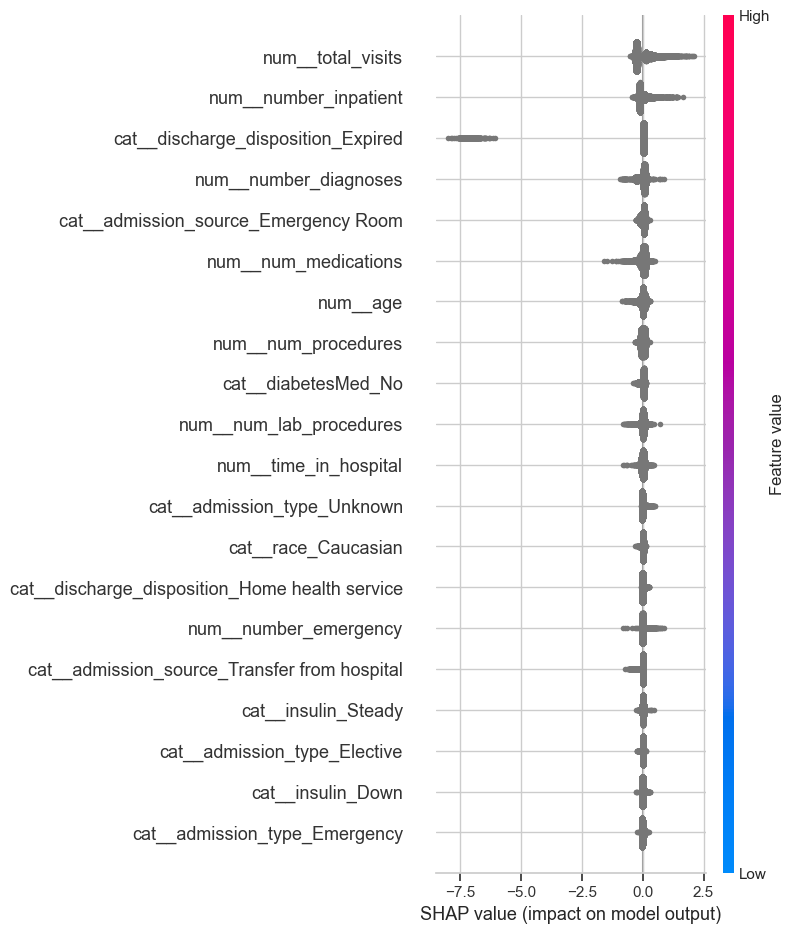

In [26]:
# ===============================================
# 9. Modeling & Evaluation
# ===============================================

import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import shap

# -----------------------------
# 9a. Train XGBoost Classifier
# -----------------------------
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)

model.fit(X_train_processed, y_train)

# -----------------------------
# 9b. Predictions & Metrics
# -----------------------------
y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# -----------------------------
# 9c. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# -----------------------------
# 9d. Feature Importance using SHAP
# -----------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed)

# Top 20 features
shap.summary_plot(shap_values, X_test_processed, feature_names=preprocessor.get_feature_names_out(), max_display=20)


## 10. Key Findings from Modeling & Clinical Interpretability

**Classification Performance:**
- Accuracy: 64%
- F1-score for readmitted patients: 0.58
- ROC-AUC: 0.70

**Confusion Matrix Highlights:**
- True Negatives: 8074
- True Positives: 5051
- False Positives: 2899
- False Negatives: 4330

**Most impactful features (from SHAP):**
- Discharge disposition (home vs SNF/home health)
- Number of prior inpatient visits
- Total healthcare utilization
- Medication burden / insulin usage

**Clinical Insights:**
- Patients with higher prior utilization or complex discharge plans are at higher readmission risk.
- Model is better at predicting non-readmissions but provides a strong baseline for clinical decision support.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 55 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  int64 
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   payer_code                61510 non-null   object
 8   medical_specialty         51817 non-null   object
 9   num_lab_procedures        101766 non-null  int64 
 10  num_procedures            101766 non-null  int64 
 11  num_medications           101766 non-null  int64 
 12  number_outpatient         101766 non-null  int64 
 13  number_emergency          101766 non-null  int64 
 14  numb

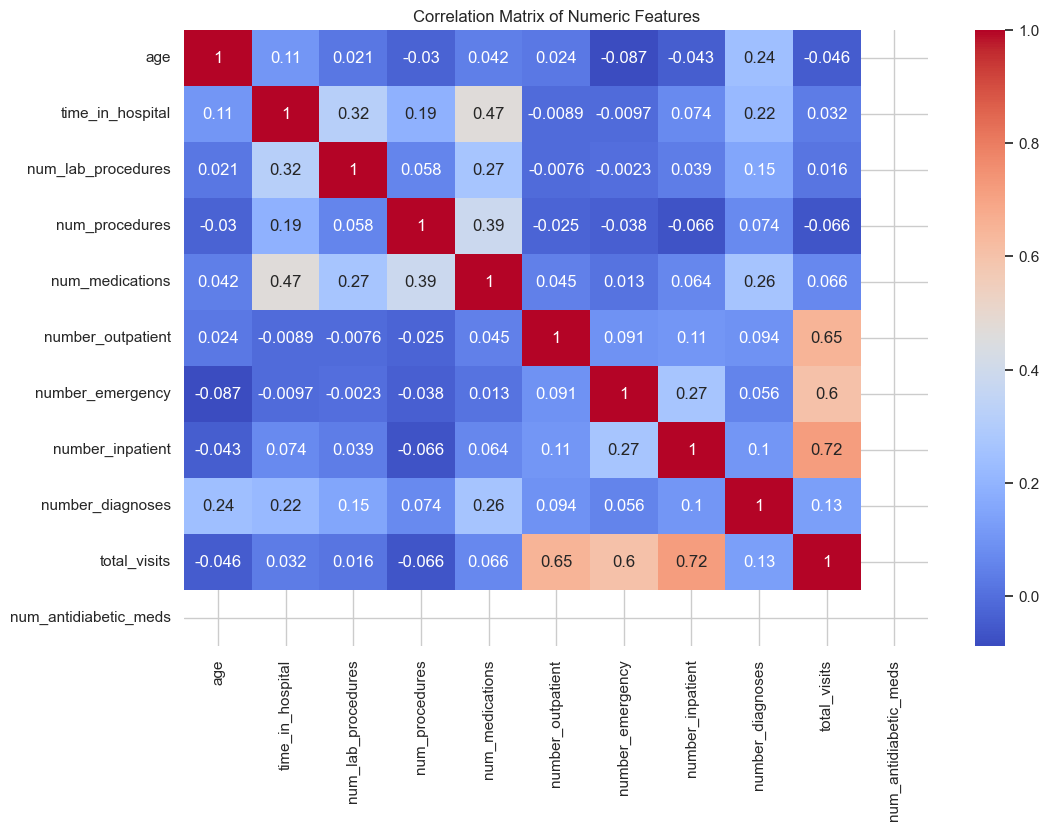

In [27]:
# ===============================================
# Dataset Inspection Commands
# ===============================================

# 1. Check general info and missing values
print(df.info())
print(df.isnull().sum())

# 2. Check target distribution
print(df['readmitted_flag'].value_counts())
print(df['readmitted_flag'].value_counts(normalize=True))

# 3. Inspect unique values for categorical variables
categorical_features = [
    'race', 'gender', 'admission_type', 'discharge_disposition',
    'admission_source', 'change', 'diabetesMed', 'insulin'
]

for col in categorical_features:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())

# 4. Inspect numeric features: summary statistics
numeric_features = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'total_visits', 'num_antidiabetic_meds'
]

print(df[numeric_features].describe())

# 5. Inspect top diagnoses
print("\nTop 10 diagnoses for diag_1:")
print(df['diag_1'].value_counts().head(10))
print("\nTop 10 diagnoses for diag_2:")
print(df['diag_2'].value_counts().head(10))
print("\nTop 10 diagnoses for diag_3:")
print(df['diag_3'].value_counts().head(10))

# 6. Check correlations among numeric features
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [28]:
corr_matrix

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,total_visits,num_antidiabetic_meds
age,1.000000,0.107515,0.020770,-0.030104,0.041847,0.023724,-0.087291,-0.042861,0.242597,-0.045940,NaN
time_in_hospital,0.107515,1.000000,0.318450,0.191472,0.466135,-0.008916,-0.009681,0.073623,0.220186,0.031708,NaN
num_lab_procedures,0.020770,0.318450,1.000000,0.058066,0.268161,-0.007602,-0.002279,0.039231,0.152773,0.016489,NaN
num_procedures,-0.030104,0.191472,0.058066,1.000000,0.385767,-0.024819,-0.038179,-0.066236,0.073734,-0.065723,NaN
num_medications,0.041847,0.466135,0.268161,0.385767,1.000000,0.045197,0.013180,0.064194,0.261526,0.065717,NaN
number_outpatient,0.023724,-0.008916,-0.007602,-0.024819,0.045197,1.000000,0.091459,0.107338,0.094152,0.649241,NaN
number_emergency,-0.087291,-0.009681,-0.002279,-0.038179,0.013180,0.091459,1.000000,0.266559,0.055539,0.603462,NaN
number_inpatient,-0.042861,0.073623,0.039231,-0.066236,0.064194,0.107338,0.266559,1.000000,0.104710,0.718618,NaN
number_diagnoses,0.242597,0.220186,0.152773,0.073734,0.261526,0.094152,0.055539,0.104710,1.000000,0.132311,NaN
total_visits,-0.045940,0.031708,0.016489,-0.065723,0.065717,0.649241,0.603462,0.718618,0.132311,1.000000,NaN


In [29]:
# ===============================================
# IMPROVED XGBOOST PIPELINE FOR READMISSION
# ===============================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb

# ---------------------------
# 1. DROP / CLEAN CATEGORICALS
# ---------------------------
# Drop rows with unknown or NULL in key categorical features
df_clean = df[
    (df['admission_type'].notnull()) & 
    (df['admission_type'] != 'NULL') &
    (df['admission_type'] != 'Not Available') &
    (df['admission_type'] != 'Not Mapped') &
    (df['discharge_disposition'].notnull()) &
    (df['admission_source'].notnull())
].copy()

# Impute race missing
df_clean['race'].fillna('Unknown', inplace=True)

# ---------------------------
# 2. ENCODE CATEGORICALS
# ---------------------------
# Insulin mapping
insulin_map = {'No': 0, 'Down': 1, 'Up': 2, 'Steady': 3}
df_clean['insulin_encoded'] = df_clean['insulin'].map(insulin_map)

# Binary columns
binary_cols = ['change', 'diabetesMed']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'No': 0, 'Ch': 1, 'Yes': 1})

# Encode admission_type, discharge_disposition, admission_source ordinally
ordinal_cols = ['admission_type', 'discharge_disposition', 'admission_source']
ord_enc = OrdinalEncoder()
df_clean[ordinal_cols] = ord_enc.fit_transform(df_clean[ordinal_cols])

# ---------------------------
# 3. CREATE AGGREGATE FEATURES
# ---------------------------
df_clean['total_visits'] = df_clean['number_outpatient'] + df_clean['number_inpatient'] + df_clean['number_emergency']
df_clean['num_antidiabetic_meds'] = df_clean[[
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride','acetohexamide','glipizide',
    'glyburide','tolbutamide','pioglitazone','rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'examide','citoglipton','insulin','glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone'
]].apply(lambda x: x.map({'No':0,'Steady':1,'Up':1,'Down':1,'Up/Steady':1,'Yes':1,'Ch':1,'Down/Up':1}).sum(), axis=1)

# ---------------------------
# 4. SELECT FEATURES AND TARGET
# ---------------------------
feature_cols = [
    'age','time_in_hospital','num_lab_procedures','num_procedures','num_medications',
    'number_outpatient','number_emergency','number_inpatient','number_diagnoses',
    'total_visits','num_antidiabetic_meds','insulin_encoded','change','diabetesMed'
] + ordinal_cols

X = df_clean[feature_cols]
y = df_clean['readmitted_flag']

# ---------------------------
# 5. TRAIN-TEST SPLIT
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------
# 6. XGBoost MODEL TRAINING
# ---------------------------
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective':'binary:logistic',
    'eval_metric':'auc',
    'eta':0.1,
    'max_depth':6,
    'subsample':0.8,
    'colsample_bytree':0.8,
    'scale_pos_weight': y_train.value_counts()[0] / y_train.value_counts()[1],  # balance classes
    'seed':42
}

num_rounds = 500

bst = xgb.train(params, dtrain, num_boost_round=num_rounds)

# ---------------------------
# 7. EVALUATION
# ---------------------------
y_pred_prob = bst.predict(dtest)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


/var/folders/8z/wt62yfwd2bj43btbm7x3jflr0000gn/T/ipykernel_6854/337317046.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['race'].fillna('Unknown', inplace=True)


Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.64      0.66     10973
           1       0.60      0.64      0.62      9381

    accuracy                           0.64     20354
   macro avg       0.64      0.64      0.64     20354
weighted avg       0.64      0.64      0.64     20354

ROC-AUC Score: 0.6934
Confusion Matrix:
 [[7043 3930]
 [3424 5957]]


In [31]:
df_clean

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,readmitted,weight_missing,admission_type,discharge_disposition,admission_source,readmitted_flag,total_visits,insulin_taken,num_antidiabetic_meds,insulin_encoded
0,Caucasian,Female,5,6,25,1,1,NaN,Pediatrics-Endocrinology,41,...,NO,1,4.0,24.0,6.0,0,0,0,0,0
1,Caucasian,Female,15,1,1,7,3,NaN,NaN,59,...,YES,1,1.0,1.0,2.0,1,0,1,1,2
2,AfricanAmerican,Female,25,1,1,7,2,NaN,NaN,11,...,NO,1,1.0,1.0,2.0,0,3,0,1,0
3,Caucasian,Male,35,1,1,7,2,NaN,NaN,44,...,NO,1,1.0,1.0,2.0,0,0,1,1,2
4,Caucasian,Male,45,1,1,7,1,NaN,NaN,51,...,NO,1,1.0,1.0,2.0,0,0,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,75,1,3,7,3,MC,NaN,51,...,YES,1,1.0,21.0,2.0,1,0,1,2,1
101762,AfricanAmerican,Female,85,1,4,5,5,MC,NaN,33,...,NO,1,1.0,20.0,9.0,0,1,1,1,3
101763,Caucasian,Male,75,1,1,7,1,MC,NaN,53,...,NO,1,1.0,1.0,2.0,0,1,1,2,1
101764,Caucasian,Female,85,2,3,7,10,MC,Surgery-General,45,...,NO,1,5.0,21.0,2.0,0,1,1,3,2
